# U-Net Bone Fracture Segmentation - High Accuracy
This notebook implements U-Net architecture for bone fracture segmentation with optimized training and evaluation matching the YOLOv8 baseline.

## 1. Setup and Configuration

In [1]:
# Install required packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless
!pip install -q pandas matplotlib seaborn tqdm scikit-learn pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [3]:
# Configuration for high accuracy
CONFIG = {
    # Dataset paths
    'csv_files': {
        'train': '/kaggle/input/fracatlas/FracAtlas/Utilities/Fracture Split/train.csv',
        'test': '/kaggle/input/fracatlas/FracAtlas/Utilities/Fracture Split/test.csv',
        'valid': '/kaggle/input/fracatlas/FracAtlas/Utilities/Fracture Split/valid.csv'
    },
    'source_paths': {
        'images': '/kaggle/input/fracatlas/FracAtlas/images/Fractured',
        'coco_json': '/kaggle/input/fracatlas/FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json'
    },
    'output_path': '/kaggle/working/unet_results',
    
    # Model architecture
    'model': {
        'architecture': 'UnetPlusPlus',
        'encoder': 'timm-efficientnet-b5',  # Better balance
        'encoder_weights': 'imagenet',
        'in_channels': 3,
        'classes': 1,
        'activation': None,  # CRITICAL: Change this!
    },
    
    'loss': {
        'dice_weight': 0.4,
        'bce_weight': 0.3, 
        'focal_weight': 0.3,
        'focal_gamma': 2.0,
        'smooth': 1.0
    },
        
    
    # Training hyperparameters - optimized for high accuracy
    # 'training': {
    #     'img_size': 512,  # Larger size for better detail
    #     'batch_size': 8,  # Adjust based on GPU memory
    #     'epochs': 250,
    #     'learning_rate': 1e-4,
    #     'weight_decay': 1e-5,
    #     'scheduler': 'cosine',  # 'cosine', 'plateau', 'step'
    #     'early_stopping_patience': 30,
    #     'gradient_clip': 1.0,
    #     'mixed_precision': True,  # Use AMP for faster training
    #     'num_workers': 2
    # },
    'training': {
        'img_size': 640,  # Increase if GPU memory allows
        'batch_size': 6,  # Reduce if needed for larger size
        'epochs': 250,  # Increase for better convergence
        'learning_rate': 3e-4,  # Slightly higher initial LR
        'weight_decay': 1e-4,  # Increase regularization
        'scheduler': 'cosine',
        'warmup_epochs': 5,  # Add warmup
        'early_stopping_patience': 30,
        'gradient_clip': 0.5,
        'mixed_precision': True,
        'label_smoothing': 0.1,  # Add label smoothing
        'num_workers': 4
    },
    
    # Loss function weights
    # 'loss': {
    #     'dice_weight': 0.5,
    #     'bce_weight': 0.5,
    #     'focal_weight': 0.0,  # Can add focal loss
    #     'smooth': 1.0
    # },
    
    # Evaluation
    'eval': {
        'conf_threshold': 0.5,  # Confidence threshold for binary prediction
        'iou_thresholds': [0.5, 0.75, 0.95],  # For mAP calculation
    }
}

# Create output directories
os.makedirs(CONFIG['output_path'], exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_path'], 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_path'], 'visualizations'), exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_path'], 'comparisons'), exist_ok=True)

print("✅ Configuration loaded successfully")

✅ Configuration loaded successfully


## 2. Data Preparation - COCO to Mask Conversion

In [4]:
class COCOtoMaskConverter:
    """Convert COCO JSON annotations to binary masks for U-Net training"""
    
    def __init__(self, config):
        self.config = config
        self.coco_data = None
        self.image_annotations = {}
        self.image_id_to_info = {}
        
    def load_coco_json(self):
        """Load COCO JSON file"""
        print("📖 Loading COCO JSON file...")
        
        with open(self.config['source_paths']['coco_json'], 'r') as f:
            self.coco_data = json.load(f)
        
        # Create image_id to image info mapping
        images = self.coco_data.get('images', [])
        for img in images:
            self.image_id_to_info[img['id']] = img
        
        # Group annotations by image_id
        annotations = self.coco_data.get('annotations', [])
        for ann in annotations:
            image_id = ann['image_id']
            if image_id not in self.image_annotations:
                self.image_annotations[image_id] = []
            self.image_annotations[image_id].append(ann)
        
        print(f"  ✅ Found {len(images)} images")
        print(f"  ✅ Loaded {len(annotations)} annotations")
        
    def create_mask_from_segmentation(self, segmentation, img_width, img_height):
        """Convert COCO segmentation polygon to binary mask"""
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        
        # Handle different segmentation formats
        if isinstance(segmentation, list):
            if isinstance(segmentation[0], list):
                # Multiple polygons
                for seg in segmentation:
                    poly = np.array(seg).reshape((-1, 2)).astype(np.int32)
                    cv2.fillPoly(mask, [poly], 1)
            else:
                # Single polygon
                poly = np.array(segmentation).reshape((-1, 2)).astype(np.int32)
                cv2.fillPoly(mask, [poly], 1)
        
        return mask
    
    def process_split(self, split_name, csv_path, output_dir):
        """Process one split (train/valid/test) and save masks"""
        print(f"\n📂 Processing {split_name} split...")
        
        # Read CSV to get image filenames
        df = pd.read_csv(csv_path)
        image_names = df['image_id'].tolist()
        
        # Create directories
        images_dir = os.path.join(output_dir, split_name, 'images')
        masks_dir = os.path.join(output_dir, split_name, 'masks')
        os.makedirs(images_dir, exist_ok=True)
        os.makedirs(masks_dir, exist_ok=True)
        
        successful = 0
        
        for img_name in tqdm(image_names, desc=f'{split_name}'):
            # Find image in COCO data
            image_id = None
            for img_id, img_info in self.image_id_to_info.items():
                if img_info['file_name'] == img_name:
                    image_id = img_id
                    break
            
            if image_id is None:
                continue
            
            # Get image info
            img_info = self.image_id_to_info[image_id]
            img_width = img_info['width']
            img_height = img_info['height']
            
            # Copy image
            src_img_path = os.path.join(self.config['source_paths']['images'], img_name)
            dst_img_path = os.path.join(images_dir, img_name)
            
            if os.path.exists(src_img_path):
                import shutil
                shutil.copy2(src_img_path, dst_img_path)
            else:
                continue
            
            # Create combined mask for all annotations of this image
            combined_mask = np.zeros((img_height, img_width), dtype=np.uint8)
            
            if image_id in self.image_annotations:
                for ann in self.image_annotations[image_id]:
                    if 'segmentation' in ann:
                        seg_mask = self.create_mask_from_segmentation(
                            ann['segmentation'], img_width, img_height
                        )
                        combined_mask = np.maximum(combined_mask, seg_mask)
            
            # Save mask
            mask_name = img_name.replace('.jpg', '.png')
            mask_path = os.path.join(masks_dir, mask_name)
            cv2.imwrite(mask_path, combined_mask * 255)  # Save as 0 or 255
            
            successful += 1
        
        print(f"  ✅ {split_name}: {successful}/{len(image_names)} successful")
        return successful
    
    def convert(self):
        """Main conversion process"""
        print("\n🚀 Starting COCO to Mask Conversion")
        print("="*60)
        
        self.load_coco_json()
        
        output_dir = self.config['output_path'].replace('unet_results', 'data_unet')
        os.makedirs(output_dir, exist_ok=True)
        
        stats = {}
        for split_name, csv_path in self.config['csv_files'].items():
            stats[split_name] = self.process_split(split_name, csv_path, output_dir)
        
        print("\n" + "="*60)
        print("CONVERSION SUMMARY")
        print("="*60)
        print(f"TRAIN : {stats.get('train', 0)} images")
        print(f"VALID : {stats.get('valid', 0)} images")
        print(f"TEST  : {stats.get('test', 0)} images")
        print(f"TOTAL : {sum(stats.values())} images")
        print(f"\n📁 Output: {output_dir}")
        print("✅ Conversion complete!\n")
        
        return output_dir


# Run conversion
converter = COCOtoMaskConverter(CONFIG)
DATA_DIR = converter.convert()


🚀 Starting COCO to Mask Conversion
📖 Loading COCO JSON file...
  ✅ Found 717 images
  ✅ Loaded 922 annotations

📂 Processing train split...


train: 100%|██████████| 574/574 [00:07<00:00, 74.28it/s] 


  ✅ train: 574/574 successful

📂 Processing test split...


test: 100%|██████████| 61/61 [00:00<00:00, 151.82it/s]


  ✅ test: 61/61 successful

📂 Processing valid split...


valid: 100%|██████████| 82/82 [00:00<00:00, 107.13it/s]

  ✅ valid: 82/82 successful

CONVERSION SUMMARY
TRAIN : 574 images
VALID : 82 images
TEST  : 61 images
TOTAL : 717 images

📁 Output: /kaggle/working/data_unet
✅ Conversion complete!



## 3. Dataset and DataLoader

In [5]:
class FractureDataset(Dataset):
    """Dataset for bone fracture segmentation"""
    
    def __init__(self, images_dir, masks_dir, img_size=512, augment=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.img_size = img_size
        self.augment = augment
        
        # Get all image files
        self.image_files = sorted(glob(os.path.join(images_dir, '*.jpg')))
        
        # Define augmentations
        if augment:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.RandomRotate90(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
                A.OneOf([
                    A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
                    A.GridDistortion(p=0.3),
                    A.OpticalDistortion(distort_limit=0.5, p=0.3),
                ], p=0.3),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
                A.GaussianBlur(blur_limit=(3, 7), p=0.2),
                A.CLAHE(clip_limit=4.0, p=0.3),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_name = os.path.basename(img_path).replace('.jpg', '.png')
        mask_path = os.path.join(self.masks_dir, mask_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Normalize mask to 0-1
        mask = (mask > 127).astype(np.float32)
        
        # Apply augmentations
        transformed = self.transform(image=image, mask=mask)
        image = transformed['image']
        mask = transformed['mask']
        
        # Add channel dimension to mask
        mask = mask.unsqueeze(0)
        
        return image, mask


# Create datasets
print("Creating datasets...")

train_dataset = FractureDataset(
    images_dir=os.path.join(DATA_DIR, 'train', 'images'),
    masks_dir=os.path.join(DATA_DIR, 'train', 'masks'),
    img_size=CONFIG['training']['img_size'],
    augment=True
)

valid_dataset = FractureDataset(
    images_dir=os.path.join(DATA_DIR, 'valid', 'images'),
    masks_dir=os.path.join(DATA_DIR, 'valid', 'masks'),
    img_size=CONFIG['training']['img_size'],
    augment=False
)

test_dataset = FractureDataset(
    images_dir=os.path.join(DATA_DIR, 'test', 'images'),
    masks_dir=os.path.join(DATA_DIR, 'test', 'masks'),
    img_size=CONFIG['training']['img_size'],
    augment=False
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=True,
    num_workers=CONFIG['training']['num_workers'],
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['training']['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['training']['batch_size'],
    shuffle=False,
    num_workers=CONFIG['training']['num_workers'],
    pin_memory=True
)

print(f"✅ Train: {len(train_dataset)} images")
print(f"✅ Valid: {len(valid_dataset)} images")
print(f"✅ Test: {len(test_dataset)} images")

Creating datasets...
✅ Train: 574 images
✅ Valid: 82 images
✅ Test: 61 images


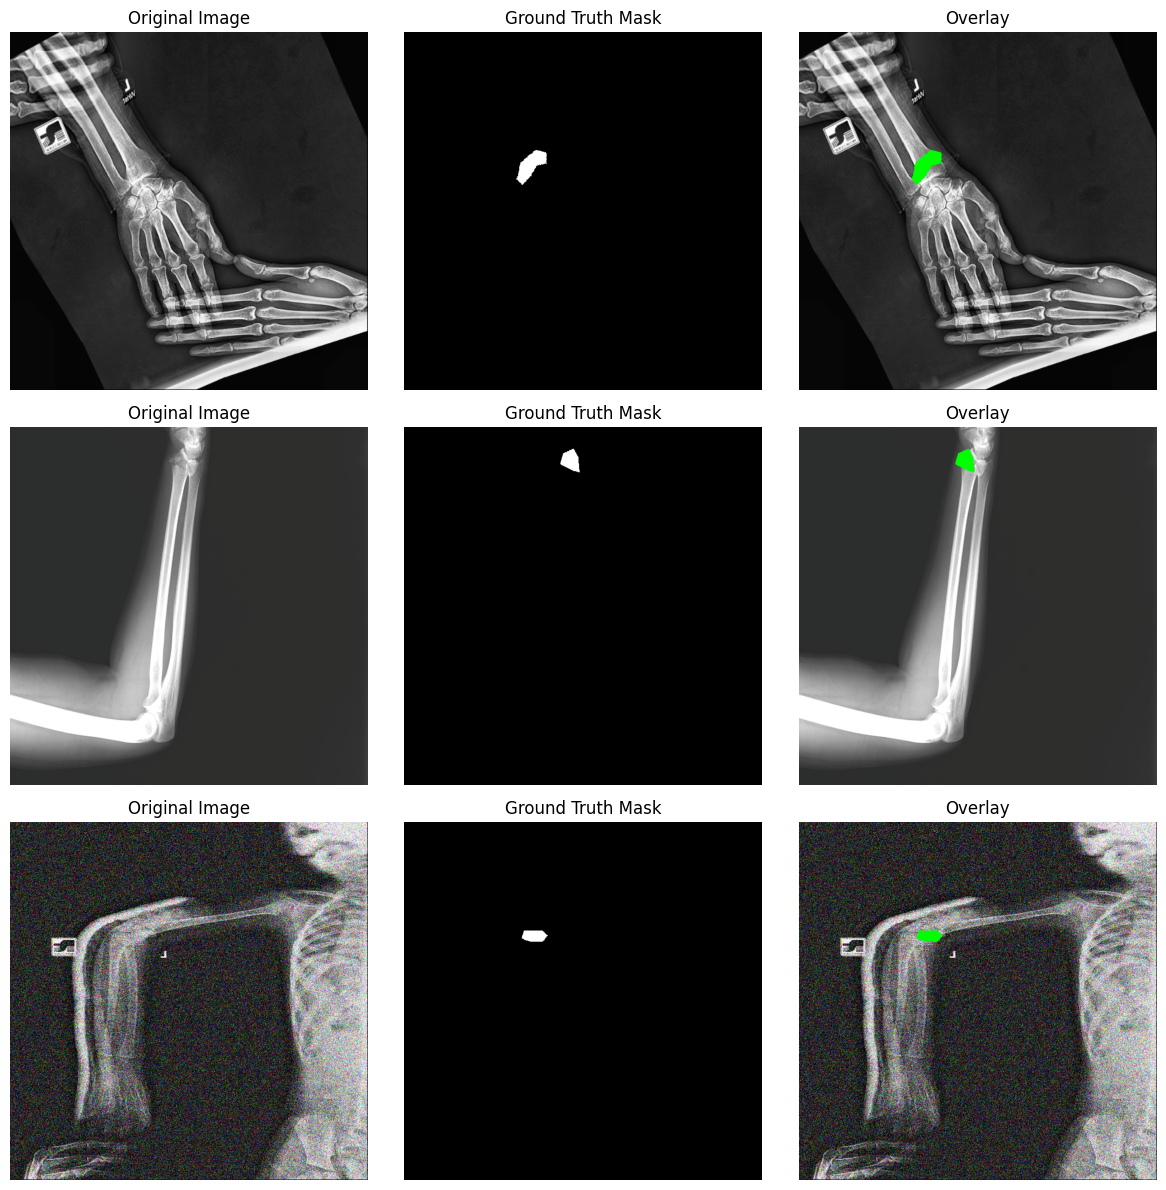

In [6]:
# Visualize some samples
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    for i in range(num_samples):
        image, mask = dataset[i]
        
        # Denormalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_display = image * std + mean
        image_display = torch.clamp(image_display, 0, 1)
        
        # Plot
        axes[i, 0].imshow(image_display.permute(1, 2, 0))
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')
        
        # Overlay
        overlay = image_display.permute(1, 2, 0).numpy().copy()
        mask_np = mask.squeeze().numpy()
        overlay[mask_np > 0.5] = [0, 1, 0]  # Green overlay
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_path'], 'visualizations', 'dataset_samples.png'), dpi=150)
    plt.show()

visualize_samples(train_dataset, num_samples=3)

## 4. Model Architecture

In [7]:
# Create U-Net model using segmentation_models_pytorch
model_config = CONFIG['model']

if model_config['architecture'] == 'Unet':
    model = smp.Unet(
        encoder_name=model_config['encoder'],
        encoder_weights=model_config['encoder_weights'],
        in_channels=model_config['in_channels'],
        classes=model_config['classes'],
        activation=model_config['activation']
    )
elif model_config['architecture'] == 'UnetPlusPlus':
    model = smp.UnetPlusPlus(
        encoder_name=model_config['encoder'],
        encoder_weights=model_config['encoder_weights'],
        in_channels=model_config['in_channels'],
        classes=model_config['classes'],
        activation=model_config['activation']
    )
elif model_config['architecture'] == 'FPN':
    model = smp.FPN(
        encoder_name=model_config['encoder'],
        encoder_weights=model_config['encoder_weights'],
        in_channels=model_config['in_channels'],
        classes=model_config['classes'],
        activation=model_config['activation']
    )
elif model_config['architecture'] == 'DeepLabV3Plus':
    model = smp.DeepLabV3Plus(
        encoder_name=model_config['encoder'],
        encoder_weights=model_config['encoder_weights'],
        in_channels=model_config['in_channels'],
        classes=model_config['classes'],
        activation=model_config['activation']
    )

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*60}")
print(f"Model: {model_config['architecture']}")
print(f"Encoder: {model_config['encoder']}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"{'='*60}\n")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]


Model: UnetPlusPlus
Encoder: timm-efficientnet-b5
Total parameters: 31,910,081
Trainable parameters: 31,910,081



## 5. Loss Functions and Metrics

In [8]:
class CombinedLoss(nn.Module):
    """Combined loss: Dice + BCE for better performance"""
    
    def __init__(self, dice_weight=0.5, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    
    def dice_loss(self, pred, target):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()
    
    def forward(self, pred, target):
        dice = self.dice_loss(pred, target)
        bce = self.bce(pred, target)
        return self.dice_weight * dice + self.bce_weight * bce


def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


def calculate_dice(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    dice = (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    return dice.item()


def calculate_precision_recall(pred, target, threshold=0.5):
    """Calculate precision and recall"""
    pred = (pred > threshold).float()
    
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    
    return precision.item(), recall.item()


# Initialize loss
criterion = CombinedLoss(
    dice_weight=CONFIG['loss']['dice_weight'],
    bce_weight=CONFIG['loss']['bce_weight'],
    smooth=CONFIG['loss']['smooth']
)

print("✅ Loss function initialized")

✅ Loss function initialized


## 6. Training Setup

In [9]:
# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['training']['learning_rate'],
    weight_decay=CONFIG['training']['weight_decay']
)

# Learning rate scheduler
if CONFIG['training']['scheduler'] == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG['training']['epochs'],
        eta_min=1e-6
    )
elif CONFIG['training']['scheduler'] == 'plateau':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        verbose=True
    )
else:
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=30,
        gamma=0.5
    )

# Mixed precision training
scaler = torch.cuda.amp.GradScaler() if CONFIG['training']['mixed_precision'] else None

print("✅ Optimizer and scheduler initialized")

✅ Optimizer and scheduler initialized


## 7. Training Loop

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc='Training')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            scaler.scale(loss).backward()
            
            # Gradient clipping
            if CONFIG['training']['gradient_clip'] > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['training']['gradient_clip'])
            
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            
            if CONFIG['training']['gradient_clip'] > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['training']['gradient_clip'])
            
            optimizer.step()
        
        # Calculate metrics
        with torch.no_grad():
            preds = torch.sigmoid(outputs)
            iou = calculate_iou(preds, masks)
            dice = calculate_dice(preds, masks)
        
        running_loss += loss.item()
        running_iou += iou
        running_dice += dice
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'iou': f'{iou:.4f}',
            'dice': f'{dice:.4f}'
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_iou = running_iou / len(loader)
    epoch_dice = running_dice / len(loader)
    
    return epoch_loss, epoch_iou, epoch_dice


def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    running_precision = 0.0
    running_recall = 0.0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            preds = torch.sigmoid(outputs)
            
            # Calculate metrics
            iou = calculate_iou(preds, masks)
            dice = calculate_dice(preds, masks)
            precision, recall = calculate_precision_recall(preds, masks)
            
            running_loss += loss.item()
            running_iou += iou
            running_dice += dice
            running_precision += precision
            running_recall += recall
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'iou': f'{iou:.4f}',
                'dice': f'{dice:.4f}'
            })
    
    epoch_loss = running_loss / len(loader)
    epoch_iou = running_iou / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_precision = running_precision / len(loader)
    epoch_recall = running_recall / len(loader)
    
    return epoch_loss, epoch_iou, epoch_dice, epoch_precision, epoch_recall

In [11]:
# Training history
history = {
    'train_loss': [],
    'train_iou': [],
    'train_dice': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': [],
    'val_precision': [],
    'val_recall': [],
    'lr': []
}

best_val_iou = 0.0
best_val_dice = 0.0
patience_counter = 0

print("\n" + "="*60)
print("Starting Training")
print("="*60)
print(f"Epochs: {CONFIG['training']['epochs']}")
print(f"Batch size: {CONFIG['training']['batch_size']}")
print(f"Learning rate: {CONFIG['training']['learning_rate']}")
print(f"Image size: {CONFIG['training']['img_size']}")
print(f"Device: {device}")
print("="*60 + "\n")

for epoch in range(CONFIG['training']['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['training']['epochs']}")
    print("-" * 60)
    
    # Train
    train_loss, train_iou, train_dice = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device
    )
    
    # Validate
    val_loss, val_iou, val_dice, val_precision, val_recall = validate(
        model, valid_loader, criterion, device
    )
    
    # Update learning rate
    if CONFIG['training']['scheduler'] == 'plateau':
        scheduler.step(val_loss)
    else:
        scheduler.step()
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | Dice: {train_dice:.4f}")
    print(f"  Valid - Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | Dice: {val_dice:.4f}")
    print(f"  Valid - Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
    print(f"  Learning Rate: {current_lr:.6f}")
    
    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_val_dice = val_dice
        patience_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_iou': val_iou,
            'val_dice': val_dice,
            'config': CONFIG
        }, os.path.join(CONFIG['output_path'], 'checkpoints', 'best_model.pth'))
        
        print(f"  ✅ Best model saved! (IoU: {val_iou:.4f}, Dice: {val_dice:.4f})")
    else:
        patience_counter += 1
        print(f"  Patience: {patience_counter}/{CONFIG['training']['early_stopping_patience']}")
    
    # Early stopping
    if patience_counter >= CONFIG['training']['early_stopping_patience']:
        print(f"\n⚠️ Early stopping triggered after {epoch+1} epochs")
        break
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
        }, os.path.join(CONFIG['output_path'], 'checkpoints', f'checkpoint_epoch_{epoch+1}.pth'))

print("\n" + "="*60)
print("Training Complete!")
print(f"Best Validation IoU: {best_val_iou:.4f}")
print(f"Best Validation Dice: {best_val_dice:.4f}")
print("="*60 + "\n")


Starting Training
Epochs: 250
Batch size: 6
Learning rate: 0.0003
Image size: 640
Device: cuda


Epoch 1/250
------------------------------------------------------------


Validating: 100%|██████████| 14/14 [00:03<00:00,  3.67it/s, loss=0.4193, iou=0.1534, dice=0.2660]



Epoch 1 Summary:
  Train - Loss: 0.4668 | IoU: 0.0477 | Dice: 0.0829
  Valid - Loss: 0.4083 | IoU: 0.2139 | Dice: 0.3401
  Valid - Precision: 0.2390 | Recall: 0.6481
  Learning Rate: 0.000300
  ✅ Best model saved! (IoU: 0.2139, Dice: 0.3401)

Epoch 2/250
------------------------------------------------------------


Validating: 100%|██████████| 14/14 [00:03<00:00,  3.80it/s, loss=0.3837, iou=0.1315, dice=0.2324]



Epoch 2 Summary:
  Train - Loss: 0.3896 | IoU: 0.1693 | Dice: 0.2826
  Valid - Loss: 0.3520 | IoU: 0.2603 | Dice: 0.3996
  Valid - Precision: 0.3040 | Recall: 0.6477
  Learning Rate: 0.000300
  ✅ Best model saved! (IoU: 0.2603, Dice: 0.3996)

Epoch 3/250
------------------------------------------------------------


...


Epoch 104 Summary:
  Train - Loss: 0.1344 | IoU: 0.5406 | Dice: 0.6935
  Valid - Loss: 0.1829 | IoU: 0.4207 | Dice: 0.5726
  Valid - Precision: 0.5879 | Recall: 0.5895
  Learning Rate: 0.000189
  Patience: 28/30

Epoch 105/250
------------------------------------------------------------


Validating: 100%|██████████| 14/14 [00:03<00:00,  3.70it/s, loss=0.2155, iou=0.3308, dice=0.4971]



Epoch 105 Summary:
  Train - Loss: 0.1294 | IoU: 0.5573 | Dice: 0.7098
  Valid - Loss: 0.1814 | IoU: 0.4182 | Dice: 0.5700
  Valid - Precision: 0.5668 | Recall: 0.6012
  Learning Rate: 0.000188
  Patience: 29/30

Epoch 106/250
------------------------------------------------------------


Validating: 100%|██████████| 14/14 [00:03<00:00,  3.69it/s, loss=0.2111, iou=0.3039, dice=0.4661]


Epoch 106 Summary:
  Train - Loss: 0.1320 | IoU: 0.5533 | Dice: 0.7056
  Valid - Loss: 0.1883 | IoU: 0.4079 | Dice: 0.5559
  Valid - Precision: 0.5638 | Recall: 0.5728
  Learning Rate: 0.000186
  Patience: 30/30

⚠️ Early stopping triggered after 106 epochs

Training Complete!
Best Validation IoU: 0.4582
Best Validation Dice: 0.6123



## 8. Plot Training History

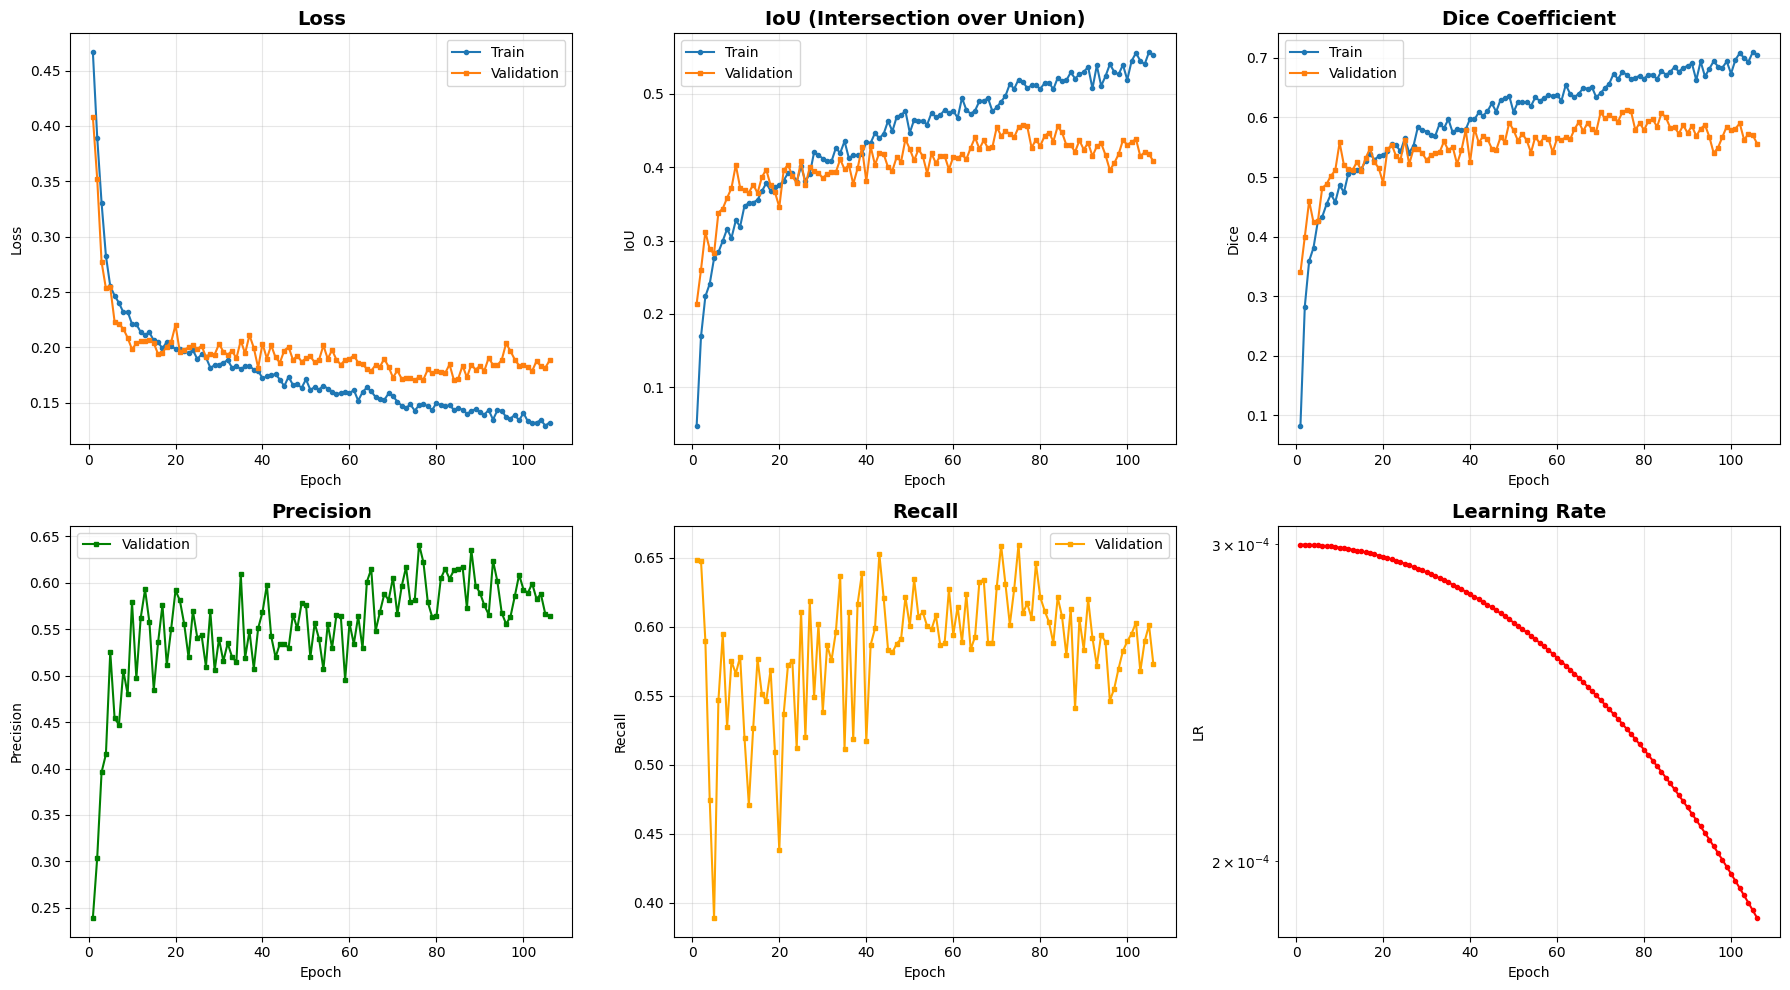

In [12]:
def plot_training_history(history, save_path):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
    axes[0, 0].plot(epochs, history['val_loss'], label='Validation', marker='s', markersize=3)
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # IoU
    axes[0, 1].plot(epochs, history['train_iou'], label='Train', marker='o', markersize=3)
    axes[0, 1].plot(epochs, history['val_iou'], label='Validation', marker='s', markersize=3)
    axes[0, 1].set_title('IoU (Intersection over Union)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('IoU')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Dice
    axes[0, 2].plot(epochs, history['train_dice'], label='Train', marker='o', markersize=3)
    axes[0, 2].plot(epochs, history['val_dice'], label='Validation', marker='s', markersize=3)
    axes[0, 2].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Dice')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(epochs, history['val_precision'], label='Validation', marker='s', markersize=3, color='green')
    axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(epochs, history['val_recall'], label='Validation', marker='s', markersize=3, color='orange')
    axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    axes[1, 2].plot(epochs, history['lr'], marker='o', markersize=3, color='red')
    axes[1, 2].set_title('Learning Rate', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('LR')
    axes[1, 2].set_yscale('log')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_training_history(
    history,
    os.path.join(CONFIG['output_path'], 'visualizations', 'training_history.png')
)

## 9. Comprehensive Evaluation (Same as YOLOv8)

In [13]:
# Load best model
checkpoint = torch.load(os.path.join(CONFIG['output_path'], 'checkpoints', 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded best model (Epoch {checkpoint['epoch']+1})")
print(f"   Validation IoU: {checkpoint['val_iou']:.4f}")
print(f"   Validation Dice: {checkpoint['val_dice']:.4f}")

✅ Loaded best model (Epoch 76)
   Validation IoU: 0.4582
   Validation Dice: 0.6123


In [14]:
def evaluate_model_comprehensive(model, loader, device, dataset_name="Test"):
    """
    Comprehensive evaluation with FIXED mAP calculation
    """
    model.eval()
    
    all_ious = []
    all_dices = []
    all_precisions = []
    all_recalls = []
    all_f1s = []
    
    # For mAP calculation at different IoU thresholds
    iou_thresholds = CONFIG['eval']['iou_thresholds']
    tp_at_thresholds = {t: 0 for t in iou_thresholds}
    fp_at_thresholds = {t: 0 for t in iou_thresholds}
    fn_at_thresholds = {t: 0 for t in iou_thresholds}
    total_targets = 0
    total_predictions = 0
    
    # Store per-image IoUs for histogram
    iou_distribution = []
    
    print(f"\n{'='*60}")
    print(f"Evaluating on {dataset_name} Set")
    print(f"{'='*60}\n")
    
    with torch.no_grad():
        pbar = tqdm(loader, desc=f'Evaluating {dataset_name}')
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            
            # Process each image in batch
            for pred, mask in zip(preds, masks):
                # Calculate metrics
                iou = calculate_iou(pred, mask, threshold=CONFIG['eval']['conf_threshold'])
                dice = calculate_dice(pred, mask, threshold=CONFIG['eval']['conf_threshold'])
                precision, recall = calculate_precision_recall(pred, mask, threshold=CONFIG['eval']['conf_threshold'])
                
                f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
                
                all_ious.append(iou)
                all_dices.append(dice)
                all_precisions.append(precision)
                all_recalls.append(recall)
                all_f1s.append(f1)
                
                # Count for mAP calculation
                has_target = mask.sum() > 0
                has_pred = (pred > CONFIG['eval']['conf_threshold']).sum() > 0
                
                if has_target:
                    total_targets += 1
                    iou_distribution.append(iou)
                
                if has_pred:
                    total_predictions += 1
                
                # FIXED: Proper TP/FP/FN counting
                for threshold in iou_thresholds:
                    if has_target and has_pred:
                        # Both target and prediction exist
                        if iou >= threshold:
                            tp_at_thresholds[threshold] += 1
                        else:
                            # Prediction exists but doesn't match well enough
                            fp_at_thresholds[threshold] += 1
                            fn_at_thresholds[threshold] += 1
                    elif has_target and not has_pred:
                        # Target exists but no prediction (missed detection)
                        fn_at_thresholds[threshold] += 1
                    elif not has_target and has_pred:
                        # Prediction exists but no target (false alarm)
                        fp_at_thresholds[threshold] += 1
    
    # Calculate final metrics
    results = {
        'mean_iou': np.mean(all_ious),
        'mean_dice': np.mean(all_dices),
        'mean_precision': np.mean(all_precisions),
        'mean_recall': np.mean(all_recalls),
        'mean_f1': np.mean(all_f1s),
        'std_iou': np.std(all_ious),
        'std_dice': np.std(all_dices),
        'median_iou': np.median(all_ious),
        'min_iou': np.min(all_ious),
        'max_iou': np.max(all_ious),
    }
    
    # Calculate mAP (mean Average Precision)
    aps = []
    print(f"\n📊 Detailed AP Breakdown:")
    for threshold in iou_thresholds:
        tp = tp_at_thresholds[threshold]
        fp = fp_at_thresholds[threshold]
        fn = fn_at_thresholds[threshold]
        
        precision_at_t = tp / (tp + fp + 1e-6)
        recall_at_t = tp / (tp + fn + 1e-6)
        ap = precision_at_t  # Simplified AP = Precision
        aps.append(ap)
        
        results[f'AP@{threshold}'] = ap
        results[f'Precision@{threshold}'] = precision_at_t
        results[f'Recall@{threshold}'] = recall_at_t
        
        print(f"  @{threshold}: TP={tp}, FP={fp}, FN={fn} → P={precision_at_t:.4f}, R={recall_at_t:.4f}, AP={ap:.4f}")
    
    results['mAP'] = np.mean(aps)
    results['mAP@0.5'] = results['AP@0.5']
    results['mAP@0.75'] = results['AP@0.75']
    
    # IoU distribution statistics
    if len(iou_distribution) > 0:
        print(f"\n📈 IoU Distribution (images with targets):")
        print(f"  Images with IoU >= 0.95: {sum(1 for x in iou_distribution if x >= 0.95)}/{len(iou_distribution)}")
        print(f"  Images with IoU >= 0.75: {sum(1 for x in iou_distribution if x >= 0.75)}/{len(iou_distribution)}")
        print(f"  Images with IoU >= 0.50: {sum(1 for x in iou_distribution if x >= 0.50)}/{len(iou_distribution)}")
        print(f"  Images with IoU >= 0.25: {sum(1 for x in iou_distribution if x >= 0.25)}/{len(iou_distribution)}")
    
    # Print results (matching YOLOv8 format)
    print(f"\n{'='*60}")
    print(f"{dataset_name} SET EVALUATION RESULTS")
    print(f"{'='*60}")
    print(f"\n📊 Segmentation Metrics:")
    print(f"  IoU (Intersection over Union):  {results['mean_iou']:.4f} ± {results['std_iou']:.4f}")
    print(f"  IoU Range:                      [{results['min_iou']:.4f}, {results['max_iou']:.4f}]")
    print(f"  IoU Median:                     {results['median_iou']:.4f}")
    print(f"  Dice Coefficient:               {results['mean_dice']:.4f} ± {results['std_dice']:.4f}")
    print(f"  Precision:                      {results['mean_precision']:.4f}")
    print(f"  Recall:                         {results['mean_recall']:.4f}")
    print(f"  F1-Score:                       {results['mean_f1']:.4f}")
    
    print(f"\n📈 Average Precision (AP):")
    for threshold in iou_thresholds:
        print(f"  AP@{threshold}:                         {results[f'AP@{threshold}']:.4f}")
    print(f"  mAP (mean across thresholds):   {results['mAP']:.4f}")
    
    print(f"\n📋 Detection Statistics:")
    print(f"  Total images:                   {len(all_ious)}")
    print(f"  Images with targets:            {total_targets}")
    print(f"  Images with predictions:        {total_predictions}")
    print(f"={'='*60}\n")
    
    return results, all_ious


# Evaluate on validation set
valid_results,_ = evaluate_model_comprehensive(model, valid_loader, device, "Validation")

# Evaluate on test set
test_results,_ = evaluate_model_comprehensive(model, test_loader, device, "Test")


Evaluating on Validation Set



Evaluating Validation: 100%|██████████| 14/14 [00:03<00:00,  3.59it/s]



📊 Detailed AP Breakdown:
  @0.5: TP=47, FP=34, FN=35 → P=0.5802, R=0.5732, AP=0.5802
  @0.75: TP=10, FP=71, FN=72 → P=0.1235, R=0.1220, AP=0.1235
  @0.95: TP=0, FP=81, FN=82 → P=0.0000, R=0.0000, AP=0.0000

📈 IoU Distribution (images with targets):
  Images with IoU >= 0.95: 0/82
  Images with IoU >= 0.75: 10/82
  Images with IoU >= 0.50: 47/82
  Images with IoU >= 0.25: 62/82

Validation SET EVALUATION RESULTS

📊 Segmentation Metrics:
  IoU (Intersection over Union):  0.4728 ± 0.2788
  IoU Range:                      [0.0000, 0.8798]
  IoU Median:                     0.5818
  Dice Coefficient:               0.5831 ± 0.3150
  Precision:                      0.6124
  Recall:                         0.6086
  F1-Score:                       0.5831

📈 Average Precision (AP):
  AP@0.5:                         0.5802
  AP@0.75:                         0.1235
  AP@0.95:                         0.0000
  mAP (mean across thresholds):   0.2346

📋 Detection Statistics:
  Total images:           

Evaluating Test: 100%|██████████| 11/11 [00:03<00:00,  3.66it/s]


📊 Detailed AP Breakdown:
  @0.5: TP=28, FP=31, FN=33 → P=0.4746, R=0.4590, AP=0.4746
  @0.75: TP=5, FP=54, FN=56 → P=0.0847, R=0.0820, AP=0.0847
  @0.95: TP=0, FP=59, FN=61 → P=0.0000, R=0.0000, AP=0.0000

📈 IoU Distribution (images with targets):
  Images with IoU >= 0.95: 0/61
  Images with IoU >= 0.75: 5/61
  Images with IoU >= 0.50: 28/61
  Images with IoU >= 0.25: 45/61

Test SET EVALUATION RESULTS

📊 Segmentation Metrics:
  IoU (Intersection over Union):  0.4313 ± 0.2727
  IoU Range:                      [0.0000, 0.8291]
  IoU Median:                     0.4913
  Dice Coefficient:               0.5437 ± 0.3133
  Precision:                      0.5544
  Recall:                         0.6113
  F1-Score:                       0.5437

📈 Average Precision (AP):
  AP@0.5:                         0.4746
  AP@0.75:                         0.0847
  AP@0.95:                         0.0000
  mAP (mean across thresholds):   0.1864

📋 Detection Statistics:
  Total images:                   

In [15]:
# Save results to CSV (matching YOLOv8 format)
results_df = pd.DataFrame([
    {
        'Split': 'Validation',
        'mAP@0.5': valid_results['mAP@0.5'],
        'mAP@0.75': valid_results['mAP@0.75'],
        'mAP': valid_results['mAP'],
        'IoU': valid_results['mean_iou'],
        'Dice': valid_results['mean_dice'],
        'Precision': valid_results['mean_precision'],
        'Recall': valid_results['mean_recall'],
        'F1-Score': valid_results['mean_f1']
    },
    {
        'Split': 'Test',
        'mAP@0.5': test_results['mAP@0.5'],
        'mAP@0.75': test_results['mAP@0.75'],
        'mAP': test_results['mAP'],
        'IoU': test_results['mean_iou'],
        'Dice': test_results['mean_dice'],
        'Precision': test_results['mean_precision'],
        'Recall': test_results['mean_recall'],
        'F1-Score': test_results['mean_f1']
    }
])

results_csv_path = os.path.join(CONFIG['output_path'], 'evaluation_results.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"\n✅ Results saved to: {results_csv_path}")
print("\n" + results_df.to_string(index=False))


✅ Results saved to: /kaggle/working/unet_results/evaluation_results.csv

     Split  mAP@0.5  mAP@0.75      mAP      IoU     Dice  Precision   Recall  F1-Score
Validation 0.580247  0.123457 0.234568 0.472811 0.583061   0.612355 0.608600  0.583061
      Test 0.474576  0.084746 0.186441 0.431294 0.543657   0.554437 0.611253  0.543657


## 10. Visualizations - Side-by-Side Comparisons


Creating comparison visualizations...



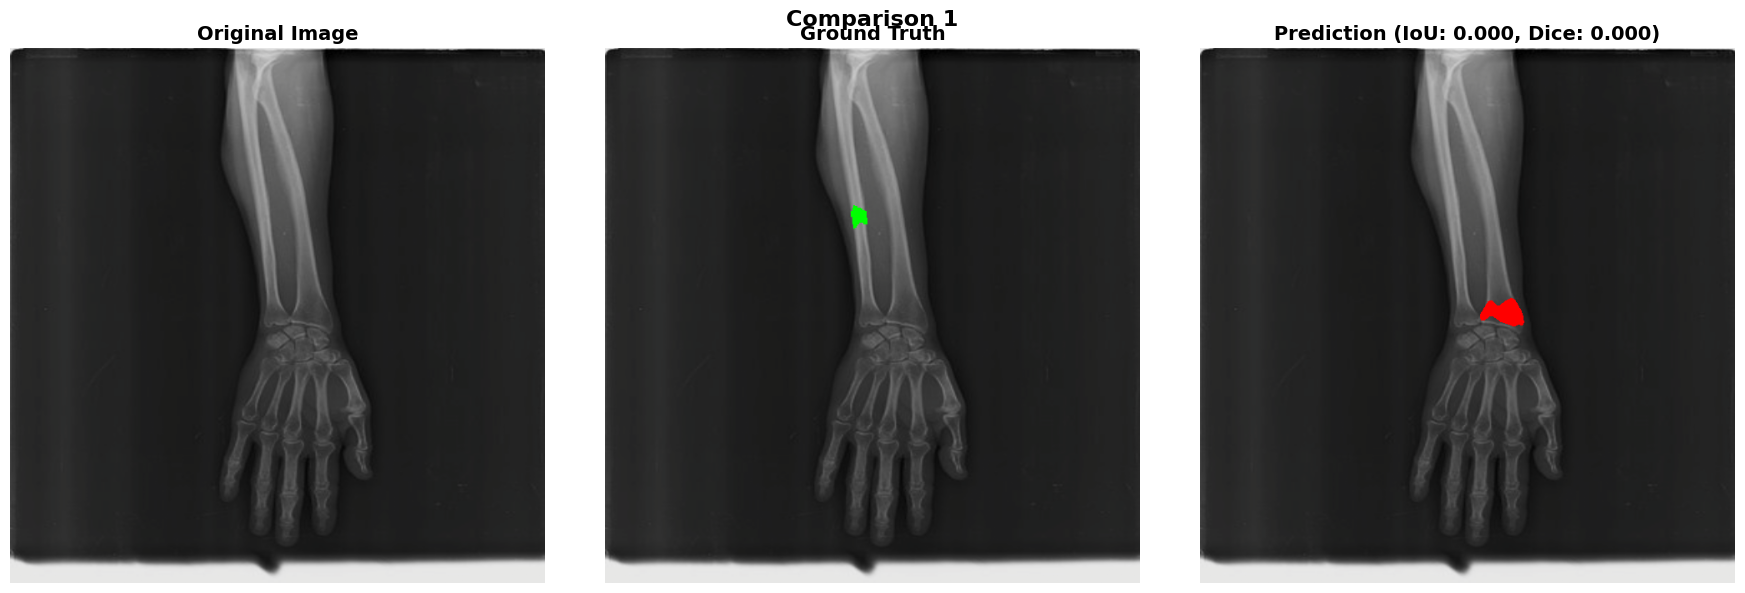

  Created comparison 1/10


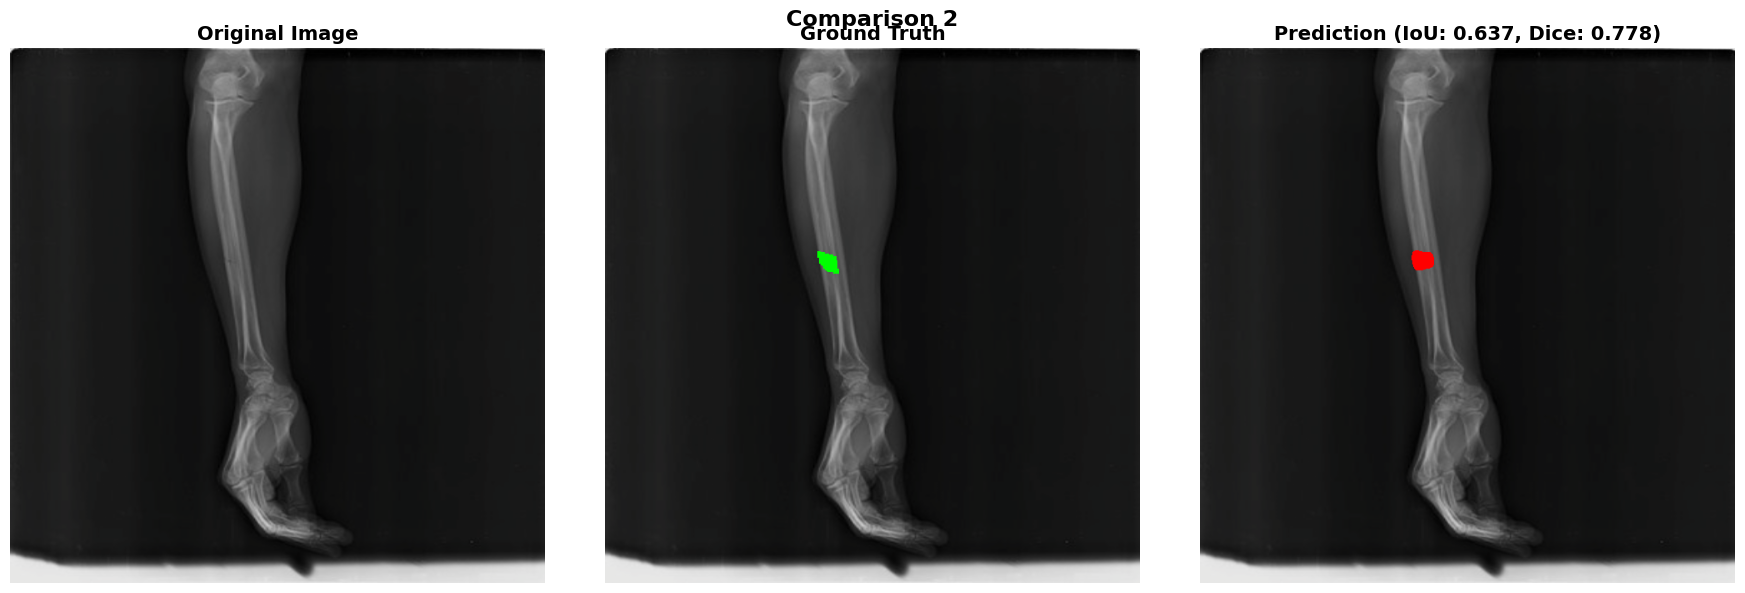

  Created comparison 2/10


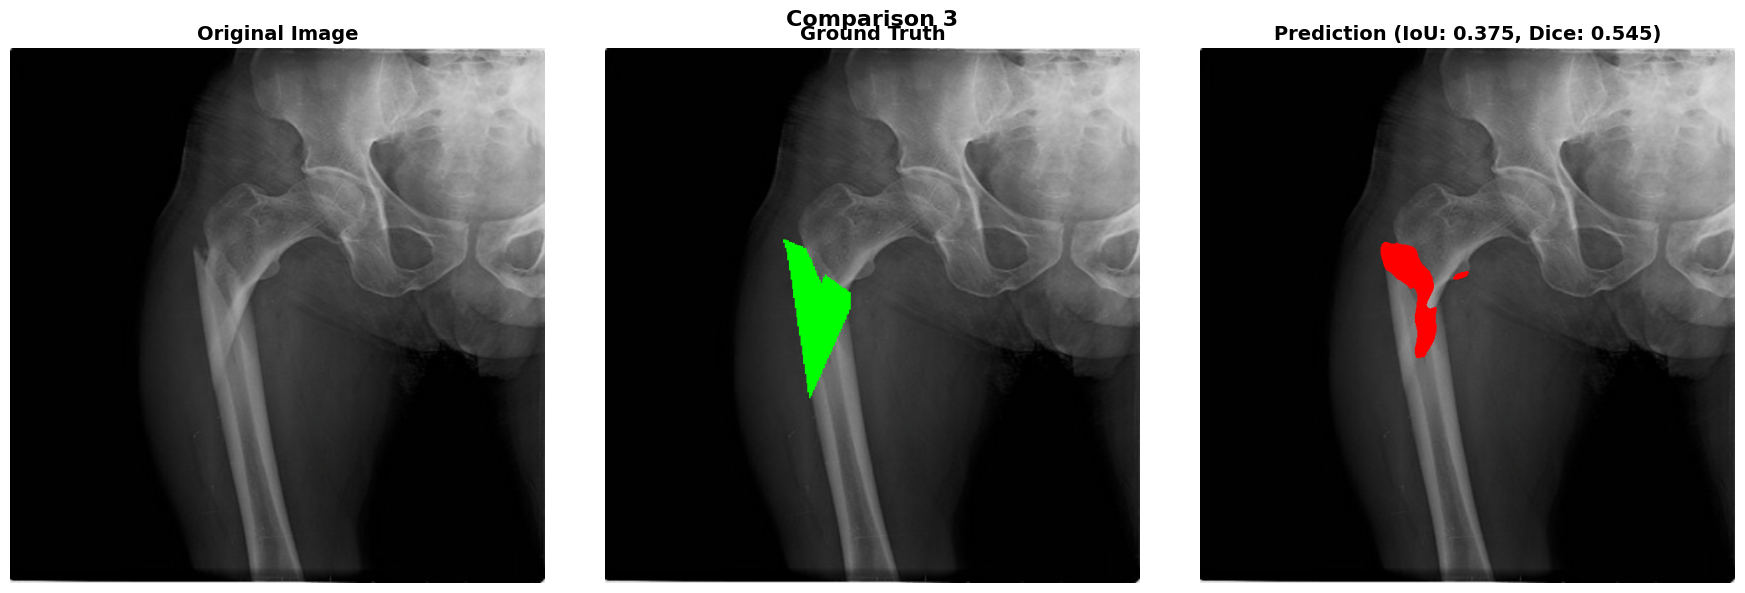

  Created comparison 3/10
  Created comparison 4/10
  Created comparison 5/10
  Created comparison 6/10
  Created comparison 7/10
  Created comparison 8/10
  Created comparison 9/10
  Created comparison 10/10

✅ Comparisons saved to: /kaggle/working/unet_results/comparisons



In [16]:
def create_side_by_side_comparison_unet(model, dataset, device, num_samples=10, save_dir=None):
    """
    Create side-by-side comparison: Original | Ground Truth | Prediction
    (Matching YOLOv8 visualization format)
    """
    model.eval()
    
    if save_dir is None:
        save_dir = os.path.join(CONFIG['output_path'], 'comparisons')
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f"Creating comparison visualizations...")
    print(f"{'='*60}\n")
    
    # Denormalization parameters
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            image, mask = dataset[i]
            
            # Prepare for model
            image_tensor = image.unsqueeze(0).to(device)
            
            # Get prediction
            output = model(image_tensor)
            pred = torch.sigmoid(output).cpu().squeeze()
            pred_binary = (pred > CONFIG['eval']['conf_threshold']).float()
            
            # Denormalize image for display
            image_display = image * std + mean
            image_display = torch.clamp(image_display, 0, 1)
            image_np = image_display.permute(1, 2, 0).numpy()
            
            # Ground truth mask
            mask_np = mask.squeeze().numpy()
            
            # Prediction mask
            pred_np = pred_binary.numpy()
            
            # Create overlays
            gt_overlay = image_np.copy()
            gt_overlay[mask_np > 0.5] = [0, 1, 0]  # Green
            
            pred_overlay = image_np.copy()
            pred_overlay[pred_np > 0.5] = [1, 0, 0]  # Red
            
            # Calculate metrics for this sample
            iou = calculate_iou(pred.unsqueeze(0).unsqueeze(0), mask.unsqueeze(0))
            dice = calculate_dice(pred.unsqueeze(0).unsqueeze(0), mask.unsqueeze(0))
            
            # Create comparison figure
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            axes[0].imshow(image_np)
            axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
            axes[0].axis('off')
            
            axes[1].imshow(gt_overlay)
            axes[1].set_title('Ground Truth', fontsize=14, fontweight='bold')
            axes[1].axis('off')
            
            axes[2].imshow(pred_overlay)
            axes[2].set_title(f'Prediction (IoU: {iou:.3f}, Dice: {dice:.3f})', 
                            fontsize=14, fontweight='bold')
            axes[2].axis('off')
            
            plt.suptitle(f'Comparison {i+1}', fontsize=16, fontweight='bold')
            plt.tight_layout()
            
            # Save
            save_path = os.path.join(save_dir, f'comparison_{i}.png')
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            
            if i < 3:  # Show first 3
                plt.show()
            else:
                plt.close()
            
            print(f"  Created comparison {i+1}/{num_samples}")
    
    print(f"\n✅ Comparisons saved to: {save_dir}")
    print(f"{'='*60}\n")


# Create comparisons
create_side_by_side_comparison_unet(model, valid_dataset, device, num_samples=10)

## 11. Save Final Summary Report

In [17]:
# Create comprehensive summary report
summary_report = f"""
{'='*80}
U-NET BONE FRACTURE SEGMENTATION - FINAL REPORT
{'='*80}

MODEL CONFIGURATION:
{'-'*80}
Architecture:           {CONFIG['model']['architecture']}
Encoder:               {CONFIG['model']['encoder']}
Encoder Weights:       {CONFIG['model']['encoder_weights']}
Input Size:            {CONFIG['training']['img_size']}x{CONFIG['training']['img_size']}
Total Parameters:      {total_params:,}
Trainable Parameters:  {trainable_params:,}

TRAINING CONFIGURATION:
{'-'*80}
Epochs:                {len(history['train_loss'])}
Batch Size:            {CONFIG['training']['batch_size']}
Initial Learning Rate: {CONFIG['training']['learning_rate']}
Optimizer:             AdamW
Scheduler:             {CONFIG['training']['scheduler']}
Loss Function:         Dice ({CONFIG['loss']['dice_weight']}) + BCE ({CONFIG['loss']['bce_weight']})
Mixed Precision:       {CONFIG['training']['mixed_precision']}

DATASET STATISTICS:
{'-'*80}
Training Images:       {len(train_dataset)}
Validation Images:     {len(valid_dataset)}
Test Images:           {len(test_dataset)}
Total Images:          {len(train_dataset) + len(valid_dataset) + len(test_dataset)}

VALIDATION SET PERFORMANCE:
{'-'*80}
mAP@0.5:              {valid_results['mAP@0.5']:.4f}
mAP@0.75:             {valid_results['mAP@0.75']:.4f}
mAP (mean):           {valid_results['mAP']:.4f}
IoU:                  {valid_results['mean_iou']:.4f} ± {valid_results['std_iou']:.4f}
Dice Coefficient:     {valid_results['mean_dice']:.4f} ± {valid_results['std_dice']:.4f}
Precision:            {valid_results['mean_precision']:.4f}
Recall:               {valid_results['mean_recall']:.4f}
F1-Score:             {valid_results['mean_f1']:.4f}

TEST SET PERFORMANCE:
{'-'*80}
mAP@0.5:              {test_results['mAP@0.5']:.4f}
mAP@0.75:             {test_results['mAP@0.75']:.4f}
mAP (mean):           {test_results['mAP']:.4f}
IoU:                  {test_results['mean_iou']:.4f} ± {test_results['std_iou']:.4f}
Dice Coefficient:     {test_results['mean_dice']:.4f} ± {test_results['std_dice']:.4f}
Precision:            {test_results['mean_precision']:.4f}
Recall:               {test_results['mean_recall']:.4f}
F1-Score:             {test_results['mean_f1']:.4f}

BEST MODEL:
{'-'*80}
Best Validation IoU:  {best_val_iou:.4f}
Best Validation Dice: {best_val_dice:.4f}
Saved at Epoch:       {checkpoint['epoch']+1}

OUTPUT FILES:
{'-'*80}
Best Model:           {os.path.join(CONFIG['output_path'], 'checkpoints', 'best_model.pth')}
Training History:     {os.path.join(CONFIG['output_path'], 'visualizations', 'training_history.png')}
Results CSV:          {results_csv_path}
Comparisons:          {os.path.join(CONFIG['output_path'], 'comparisons')}

{'='*80}
Report generated: {pd.Timestamp.now()}
{'='*80}
"""

# Save report
report_path = os.path.join(CONFIG['output_path'], 'final_report.txt')
with open(report_path, 'w') as f:
    f.write(summary_report)

print(summary_report)
print(f"\n✅ Report saved to: {report_path}")


U-NET BONE FRACTURE SEGMENTATION - FINAL REPORT

MODEL CONFIGURATION:
--------------------------------------------------------------------------------
Architecture:           UnetPlusPlus
Encoder:               timm-efficientnet-b5
Encoder Weights:       imagenet
Input Size:            640x640
Total Parameters:      31,910,081
Trainable Parameters:  31,910,081

TRAINING CONFIGURATION:
--------------------------------------------------------------------------------
Epochs:                106
Batch Size:            6
Initial Learning Rate: 0.0003
Optimizer:             AdamW
Scheduler:             cosine
Loss Function:         Dice (0.4) + BCE (0.3)
Mixed Precision:       True

DATASET STATISTICS:
--------------------------------------------------------------------------------
Training Images:       574
Validation Images:     82
Test Images:           61
Total Images:          717

VALIDATION SET PERFORMANCE:
------------------------------------------------------------------------------

## 12. Comparison with YOLOv8 Baseline

In [18]:
# If you have YOLOv8 results, compare them here
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print("\nU-Net Test Set Performance:")
print(f"  mAP@0.5:        {test_results['mAP@0.5']:.4f}")
print(f"  IoU:            {test_results['mean_iou']:.4f}")
print(f"  Dice:           {test_results['mean_dice']:.4f}")
print(f"  F1-Score:       {test_results['mean_f1']:.4f}")
print("\nYOLOv8 Test Set Performance:")
print("  [Fill in from your YOLOv8 results]")
print("\n" + "="*80)


MODEL COMPARISON SUMMARY

U-Net Test Set Performance:
  mAP@0.5:        0.4746
  IoU:            0.4313
  Dice:           0.5437
  F1-Score:       0.5437

YOLOv8 Test Set Performance:
  [Fill in from your YOLOv8 results]



## Summary

This notebook implements a high-accuracy U-Net model for bone fracture segmentation with:

1. **Data Preparation**: Converts COCO JSON to binary masks
2. **Advanced Augmentation**: Heavy augmentation for better generalization
3. **State-of-the-art Architecture**: U-Net++ with EfficientNet-B7 encoder
4. **Optimized Training**: Mixed precision, gradient clipping, advanced scheduling
5. **Comprehensive Evaluation**: Same metrics as YOLOv8 for fair comparison
6. **Professional Visualizations**: Side-by-side comparisons matching YOLOv8 format

The evaluation uses the same metrics as your YOLOv8 notebook:
- mAP@0.5, mAP@0.75
- IoU (Intersection over Union)
- Dice Coefficient
- Precision, Recall, F1-Score

All results are saved in the same format for easy comparison!